In [1]:
from cellmender.simulation import simulate_cells
from cellmender.simulation import simple_simulation
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
data = simple_simulation()
print(data)

AnnData object with n_obs × n_vars = 5000 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction'
    var: 'ambient_profile'
    uns: 'simulation_params', 'type_profiles'


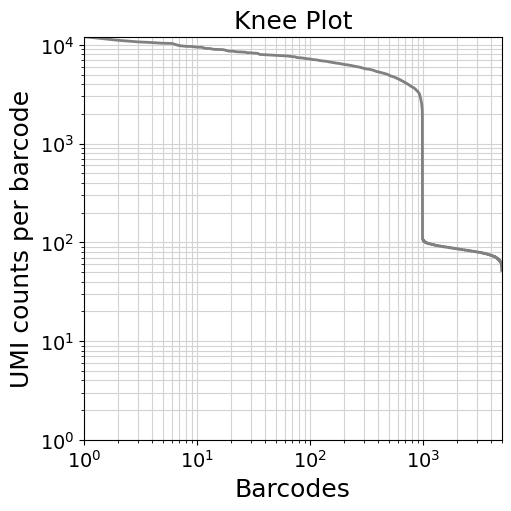

In [3]:
cm_utils.knee_plot(data)

In [4]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")
denoised_data = denoise_count_matrix(data, max_iter=150, beta=0.03, cell_ambient_fraction=0.01, verbose=2, adata_out = adata_cellmender_path, log_file = adata_log_path)

21:42:14 - INFO - Inferring gene ambient fractions.
21:42:14 - INFO - Added 'ambient_fraction' to adata.var.
21:42:14 - INFO - Inferring celltype profiles.
21:42:14 - INFO - Number of parameters in the cellmender model: 27,921 (alpha_i: 992, beta: 1, gamma_type: 8,928, p_k: 18,000)
21:42:14 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
21:42:14 - INFO - Performing Sparse EM with 1 Numba threads


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


21:42:15 - INFO - EM Iter   1: ll=-33939883.274 mean_alpha=0.059995 beta=0.011567
21:42:15 - INFO - EM Iter   2: ll=-27535368.687 mean_alpha=0.109369 beta=0.001276
21:42:15 - INFO - EM Iter   3: ll=-24785273.489 mean_alpha=0.159098 beta=0.000083
21:42:15 - INFO - EM Iter   4: ll=-23038698.942 mean_alpha=0.209011 beta=0.000004
21:42:15 - INFO - EM Iter   5: ll=-21753468.690 mean_alpha=0.258943 beta=0.000000
21:42:15 - INFO - EM Iter   6: ll=-20735958.027 mean_alpha=0.308752 beta=0.000000
21:42:15 - INFO - EM Iter   7: ll=-19895035.501 mean_alpha=0.358306 beta=0.000000
21:42:15 - INFO - EM Iter   8: ll=-19180061.707 mean_alpha=0.407478 beta=0.000000
21:42:15 - INFO - EM Iter   9: ll=-18559942.586 mean_alpha=0.456122 beta=0.000000
21:42:15 - INFO - EM Iter  10: ll=-18014232.344 mean_alpha=0.504122 beta=0.000000
21:42:16 - INFO - EM Iter  11: ll=-17528792.237 mean_alpha=0.551347 beta=0.000000
21:42:16 - INFO - EM Iter  12: ll=-17093461.711 mean_alpha=0.597655 beta=0.000000
21:42:16 - INFO 

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


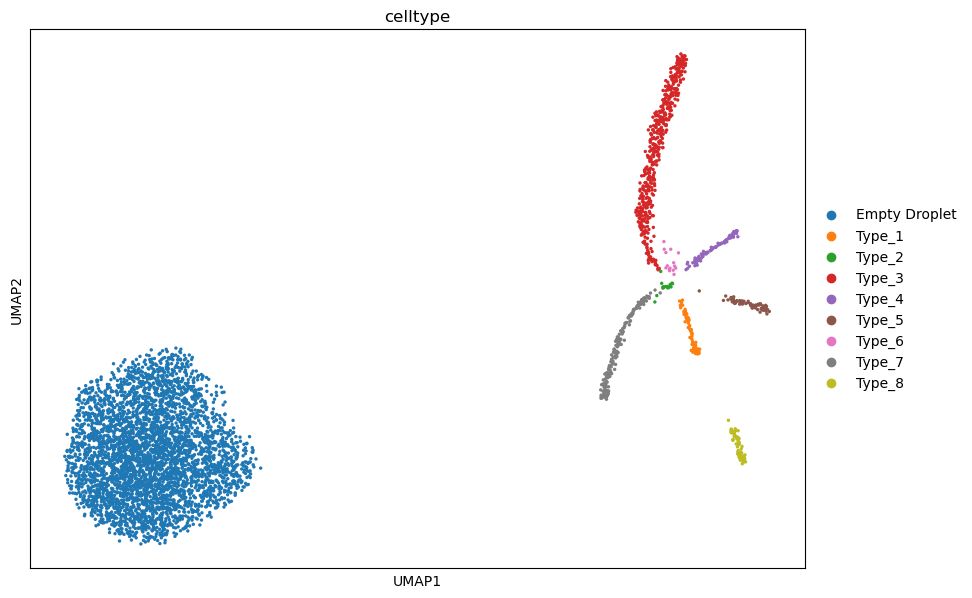

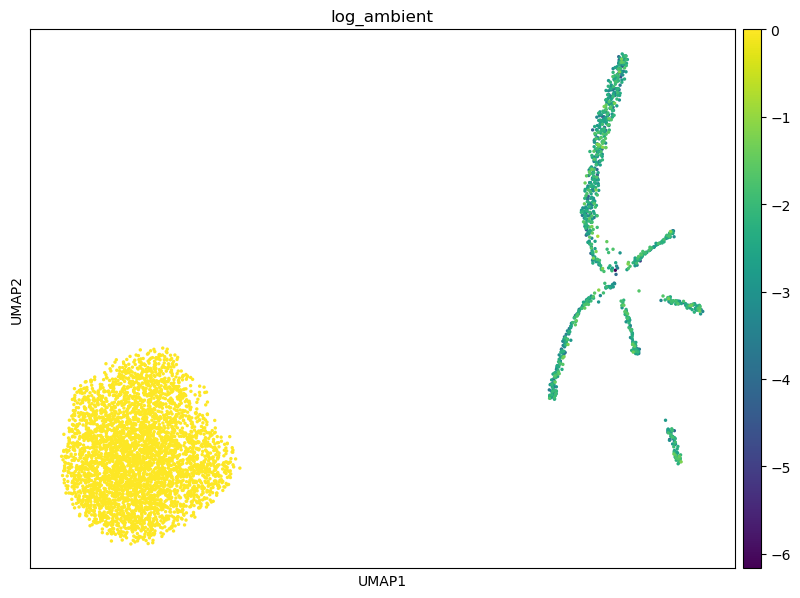

In [5]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [6]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

           cellid celltype  is_empty  ambient_fraction  cell_ambient_fraction  \
cell_1          1   Type_1     False          0.122659                   0.01   
cell_9          3   Type_3     False          0.132257                   0.01   
cell_18         7   Type_7     False          0.058414                   0.01   
cell_21         7   Type_7     False          0.060366                   0.01   
cell_31         3   Type_3     False          0.109593                   0.01   
...           ...      ...       ...               ...                    ...   
cell_4981       1   Type_1     False          0.061459                   0.01   
cell_4987       7   Type_7     False          0.030260                   0.01   
cell_4988       4   Type_4     False          0.081189                   0.01   
cell_4991       5   Type_5     False          0.088232                   0.01   
cell_4997       4   Type_4     False          0.124780                   0.01   

           alpha_hat  z_hat

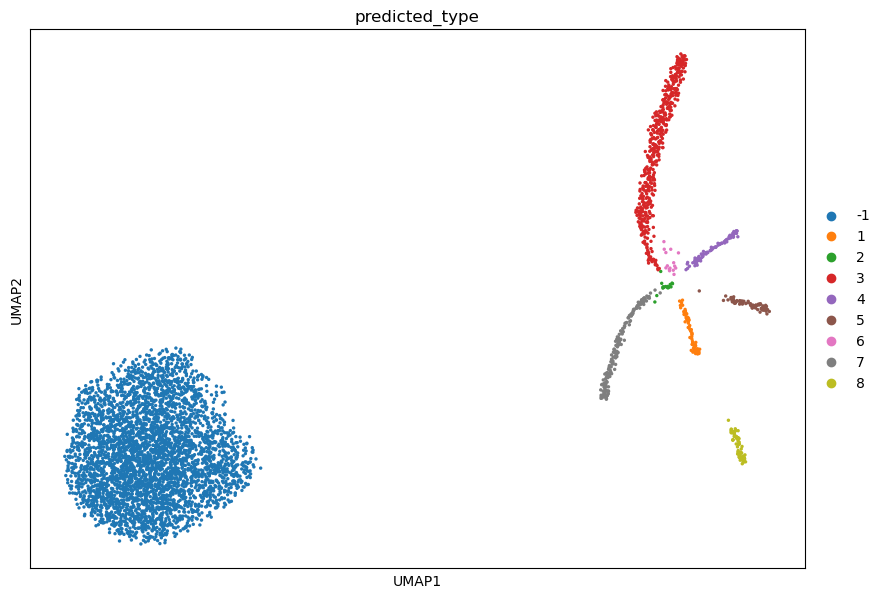

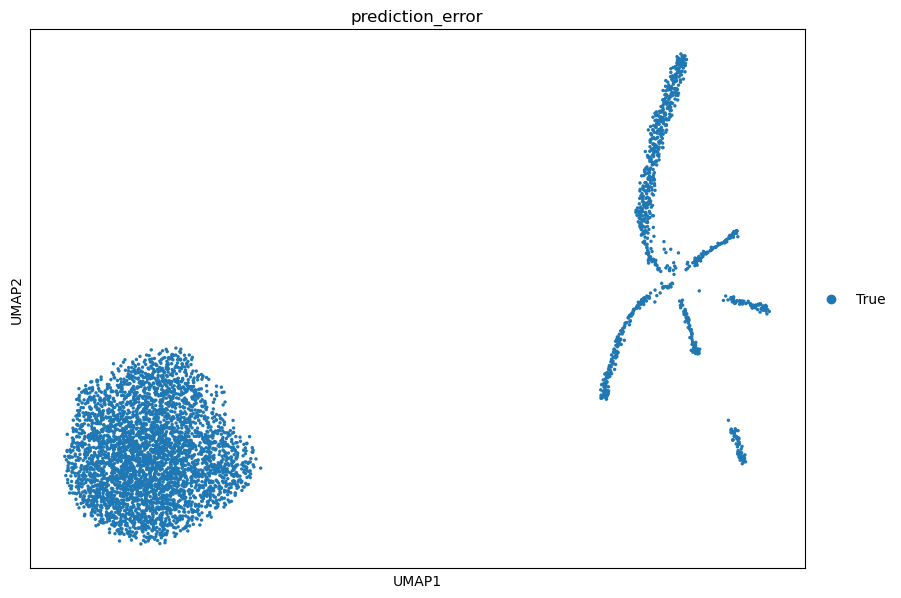

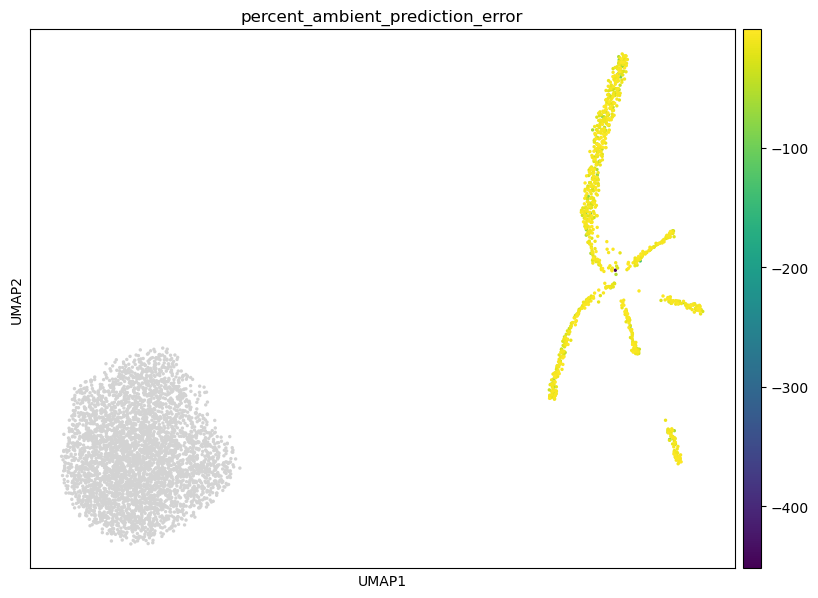

In [7]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'] == denoised_data.obs['cellid'])

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)